In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display


In [2]:
# 1. Define our State
class AgentState(TypedDict):
    query: str
    sentiment: str # 'positive' or 'negative'

In [3]:
# 2. Our Worker Node
def analyze_sentiment(state: AgentState):
    # Imagine an LLM call here
    if "angry" in state["query"].lower():
        return {"sentiment": "negative"}
    return {"sentiment": "positive"}

In [4]:
# 3. Our Router Function (The Logic)
def route_based_on_mood(state: AgentState) -> Literal["refund_department", "survey_node"]:
    if state["sentiment"] == "negative":
        return "refund_department"
    return "survey_node"

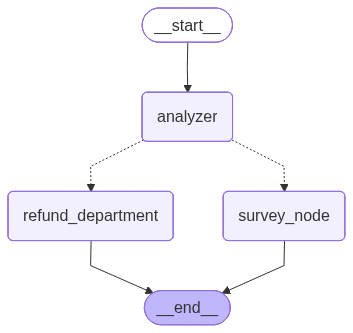

In [5]:
# 4. Building the Graph
workflow = StateGraph(AgentState)

workflow.add_node("analyzer", analyze_sentiment)
workflow.add_node("refund_department", lambda state: print("--- Routing to Human Agent ---"))
workflow.add_node("survey_node", lambda state: print("--- Sending Feedback Survey ---"))

# Define the flow
workflow.add_edge(START, "analyzer")

# The Decision Point
workflow.add_conditional_edges(
    "analyzer", 
    route_based_on_mood,
    {
        "refund_department": "refund_department",
        "survey_node": "survey_node"
    }
)

workflow.add_edge("refund_department", END)
workflow.add_edge("survey_node", END)

agent = workflow.compile()

graph_image = agent.get_graph().draw_mermaid_png()
display(Image(graph_image))